In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [87]:
df=pd.read_csv("income.csv")
print(df.head())

      Name  Age  Income
0      Rob   27   70000
1  Michael   29   90000
2    Mohan   29   61000
3   Ismail   28   60000
4     Kory   42  150000


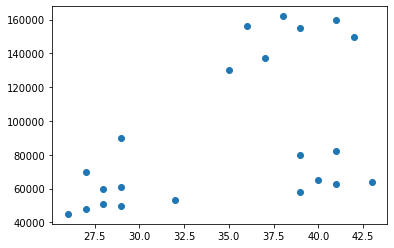

In [88]:
plt.scatter(df.Age,df['Income'])
#(df.Age,df.Income)
#(df['Age'],df['Income'])

In [89]:
km = KMeans(n_clusters=3)
y_predict = km.fit_predict(df[['Age','Income']])
y_predict

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0])

In [90]:
df['cluster']=y_predict
print(df)

        Name  Age  Income  cluster
0        Rob   27   70000        2
1    Michael   29   90000        2
2      Mohan   29   61000        0
3     Ismail   28   60000        0
4       Kory   42  150000        1
5     Gautam   39  155000        1
6      David   41  160000        1
7     Andrea   38  162000        1
8       Brad   36  156000        1
9   Angelina   35  130000        1
10    Donald   37  137000        1
11       Tom   26   45000        0
12    Arnold   27   48000        0
13     Jared   28   51000        0
14     Stark   29   49500        0
15    Ranbir   32   53000        0
16    Dipika   40   65000        0
17  Priyanka   41   63000        0
18      Nick   43   64000        0
19      Alia   39   80000        2
20       Sid   41   82000        2
21     Abdul   39   58000        0


In [91]:
df1 = df[df.cluster==0]
df2 = df[df.cluster==1]
df3 = df[df.cluster==2]
# print(df1)
# print(df2)
# print(df3)

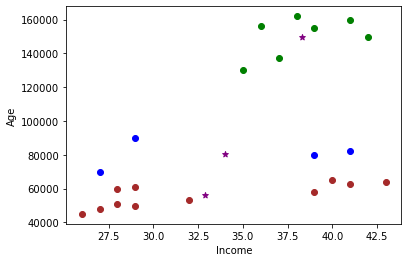

In [92]:
plt.scatter(df1.Age,df1.Income,color='brown')
plt.scatter(df2.Age,df2.Income,color='green')
plt.scatter(df3.Age,df3.Income,color='blue')
plt.xlabel('Income')
plt.ylabel('Age')
# plt.legend
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')

In [93]:
km.cluster_centers_

array([[3.29090909e+01, 5.61363636e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04]])

In [94]:
sc =MinMaxScaler()
sc.fit(df[['Income']])
df['Income']=sc.transform(df[['Income']])
sc.fit(df[['Age']])
df['Age']=sc.transform(df[['Age']])
df.head()

,Name,Age,Income,cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [96]:
sse=[]
Krng=range(1,len(df))
for i in K_rng:
        km=KMeans(n_clusters=i)
        km.fit(df[['Age','Income']])
        sse.append(km.inertia_)
sse

C:\Users\DELL\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


[5.434011511988178,
 2.0911363886990775,
 0.4750783498553096,
 0.34910470944195654,
 0.2621792762345213,
 0.21055478995472493,
 0.1685851223602976,
 0.13265419827245162,
 0.10188787724979426,
 0.08510915216361345,
 0.06359040943557256,
 0.04681168434939175,
 0.03810151092446364,
 0.030426552928992826,
 0.02336003499387405,
 0.01641649105272562,
 0.011033819491365383,
 0.00751395748512241,
 0.0054551225809321684,
 0.003578916064498534,
 0.0017666294837796928]

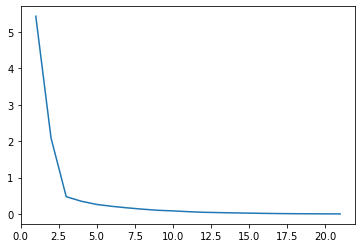

In [97]:
plt.plot(Krng,sse)